In [13]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
# ============================================================
# USER SETTINGS
# ============================================================
target_time = np.datetime64("2024-09-27T00:00")

# File locations
hurrywave_nc = (
    r"F:/crs/proj/2025_NOPP_comparison/helene_deltares_wave_model_output/"
    r"helene89pervmax/hurrywave_map.nc"
)

adcirc_nc = (
    r"F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/"
    r"bulk_wave_stats/allnodes_sig_waveheight_ts_swan_HS_63_orig.nc"
)

coawst_url = (
    "https://geoport.whoi.edu/thredds/dodsC/"
    "vortexfs1/usgs/Projects/Helene2024/helene77/Output_89pct/"
    "coawst_gomsab_his.nc"
)

# ============================================================
# HURRYWAVE
# ============================================================
def load_hurrywave_hm0(ncfile, target_time):
    ds = xr.open_dataset(ncfile)

    itime = ds.indexes["time"].get_indexer([target_time], method="nearest")[0]
    tsel = ds["time"].values[itime]

    hm0 = ds["hm0"].isel(time=itime).values
    x = ds["x"].values
    y = ds["y"].values
    corner_x = ds["corner_x"].values
    corner_y = ds["corner_y"].values
    msk = ds["msk"].values if "msk" in ds else None

    hm0_plot = hm0.copy()
    if msk is not None:
        hm0_plot = np.where(msk > 0, hm0_plot, np.nan)
    hm0_plot = np.where(np.isfinite(hm0_plot), hm0_plot, np.nan)

    return {
        "name": "HurryWave",
        "time": tsel,
        "x": x,
        "y": y,
        "corner_x": corner_x,
        "corner_y": corner_y,
        "z": hm0_plot,
    }

# ============================================================
# ADCIRC / SWAN
# ============================================================
def load_adcirc_hs(ncfile, target_time, correct_year=True):
    ds = xr.open_dataset(ncfile)

    time_vals = ds["time"].values
    if correct_year:
        time_vals = time_vals + np.timedelta64(731, "D")

    itime = _time_index_from_coord(time_vals, target_time)
    tsel = time_vals[itime]

    x = ds["x"].values
    y = ds["y"].values
    hs = ds["swan_HS"].isel(time=itime).values
    triangles = ds["element"].values

    start_index = ds["element"].attrs.get("start_index", 1)
    triangles = triangles.astype(np.int64) - start_index

    hs_plot = np.where(np.isfinite(hs), hs, np.nan)

    tri = mtri.Triangulation(x, y, triangles=triangles)
    tri_mask = np.any(~np.isfinite(hs_plot[triangles]), axis=1)
    tri.set_mask(tri_mask)

    return {
        "name": "ADCIRC/SWAN",
        "time": tsel,
        "x": x,
        "y": y,
        "tri": tri,
        "z": hs_plot,
    }

# ============================================================
# COAWST / WW3
# ============================================================
def load_coawst_hwave(dap_url, target_time, wave_var="Hwave"):
    ds = xr.open_dataset(dap_url)

    isel = ds.indexes["ocean_time"].get_indexer([target_time], method="nearest")[0]
    tsel = ds["ocean_time"].values[isel]

    lon = ds["lon_rho"].values
    lat = ds["lat_rho"].values
    hwave = ds[wave_var].isel(ocean_time=isel).values

    if "mask_rho" in ds:
        mask_rho = ds["mask_rho"].values
        hwave_plot = np.where(mask_rho == 1, hwave, np.nan)
    else:
        hwave_plot = hwave.copy()

    hwave_plot = np.where(np.isfinite(hwave_plot), hwave_plot, np.nan)

    return {
        "name": "COAWST/WW3",
        "time": tsel,
        "x": lon,
        "y": lat,
        "z": hwave_plot,
    }

# ============================================================
# LOAD ALL THREE
# ============================================================
extent = [lon_min, lon_max, lat_min, lat_max]

d_hw = load_hurrywave_hm0(hurrywave_nc, target_time)
d_ad = load_adcirc_hs(adcirc_nc, target_time, correct_year=True)
d_cw = load_coawst_hwave(coawst_url, target_time, wave_var="Hwave")

print("Times used:")
print("  HurryWave   :", d_hw["time"])
print("  ADCIRC/SWAN :", d_ad["time"])
print("  COAWST/WW3  :", d_cw["time"])

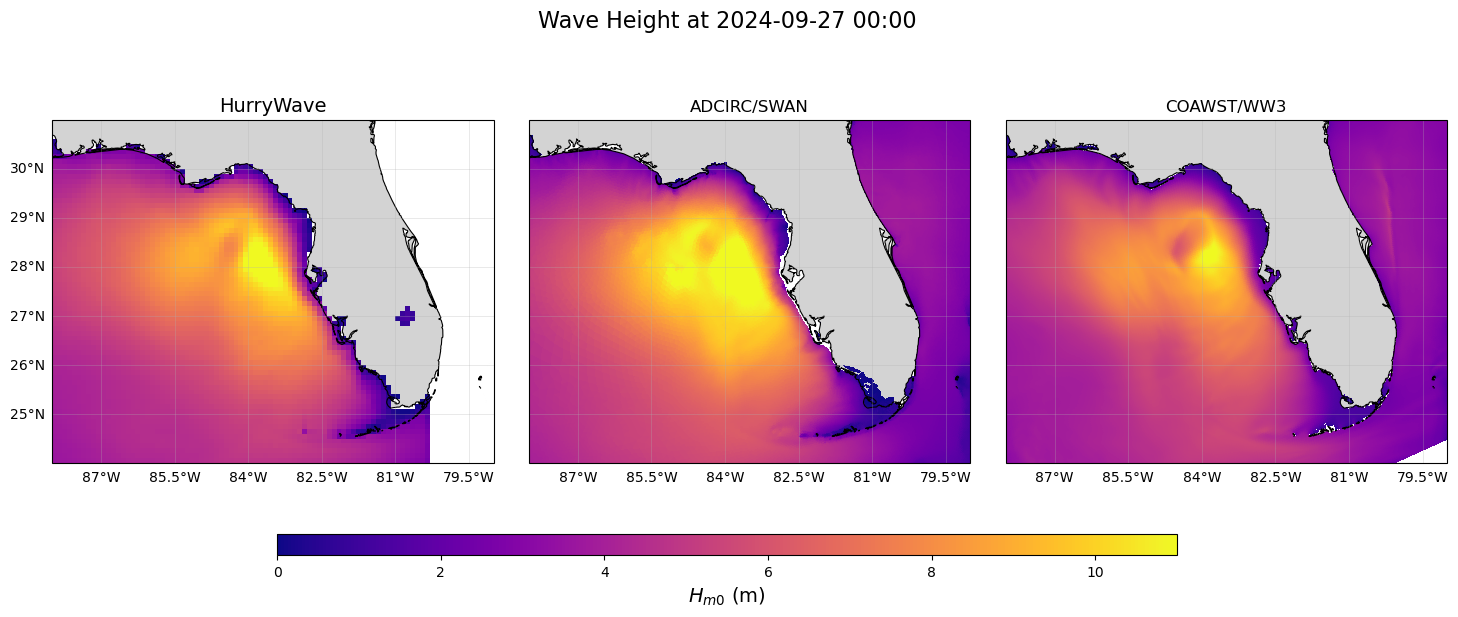

In [7]:
# ============================================================
# PLOT THREE-PANEL FIGURE
# ============================================================
# Common plot settings

# Geographic extent
lon_min, lon_max = -88.0, -79.5
lat_min, lat_max = 24.0, 31.0
extent = [lon_min, lon_max, lat_min, lat_max]
cmap = "plasma"
vmin = 0.0
vmax = 11.0

def _set_map_style(ax, extent=None, show_left_labels=True):
    ax.coastlines(resolution="10m", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = show_left_labels
    gl.bottom_labels = True
    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())


def _get_ax(fig, nrows, ncols, index):
    return fig.add_subplot(nrows, ncols, index, projection=ccrs.PlateCarree())


def _time_index_from_coord(time_vals, target_time):
    return int(np.argmin(np.abs(time_vals - target_time)))

def plot_coawst_panel(ax, d, vmin, vmax, cmap, extent, show_left_labels=True):
    pcm = ax.pcolormesh(
        d["x"], d["y"], d["z"],
        cmap=cmap, vmin=vmin, vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    _set_map_style(ax, extent=extent, show_left_labels=show_left_labels)
    ax.set_title(f'{d["name"]}')
    return pcm


def plot_adcirc_panel(ax, d, vmin, vmax, cmap, extent, show_left_labels=True):
    pcm = ax.tripcolor(
        d["tri"], d["z"],
        shading="flat",
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(),
    )

    _set_map_style(ax, extent=extent, show_left_labels=show_left_labels)
    ax.set_title(f'{d["name"]}')
    return pcm


def plot_hurrywave_panel(ax, d, vmin, vmax, cmap, extent, show_left_labels=True):
    pcm = ax.pcolormesh(
        d["corner_x"], d["corner_y"], d["z"],
        cmap=cmap, vmin=vmin, vmax=vmax,
        shading="flat",
        transform=ccrs.PlateCarree(),
    )

    _set_map_style(ax, extent=extent, show_left_labels=show_left_labels)
    ax.set_title(f'{d["name"]}', fontsize=14)
    return pcm

fig = plt.figure(figsize=(18, 6))

ax1 = _get_ax(fig, 1, 3, 1)
ax2 = _get_ax(fig, 1, 3, 2)
ax3 = _get_ax(fig, 1, 3, 3)

pcm1 = plot_hurrywave_panel(ax1, d_hw, vmin, vmax, cmap, extent, show_left_labels=True)
pcm2 = plot_adcirc_panel(ax2, d_ad, vmin, vmax, cmap, extent, show_left_labels=False)
pcm3 = plot_coawst_panel(ax3, d_cw, vmin, vmax, cmap, extent, show_left_labels=False)

# Leave room for bottom colorbar
fig.subplots_adjust(bottom=0.18, wspace=0.08)

# Horizontal colorbar across the bottom
cbar_ax = fig.add_axes([0.25, 0.09, 0.50, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(pcm3, cax=cbar_ax, orientation="horizontal")
cbar.set_label("$H_{m0}$ (m)", fontsize=14)

# Ensure ticks/label are on bottom (default, but explicit)
cbar.ax.xaxis.set_label_position("bottom")
cbar.ax.xaxis.set_ticks_position("bottom")

fig.suptitle("Wave Height at 2024-09-27 00:00", y=1., fontsize=16)
plt.savefig('F:/crs/proj/2025_NOPP_comparison/helene_figs/three_panel_Hmo.png', dpi=300)
plt.show()

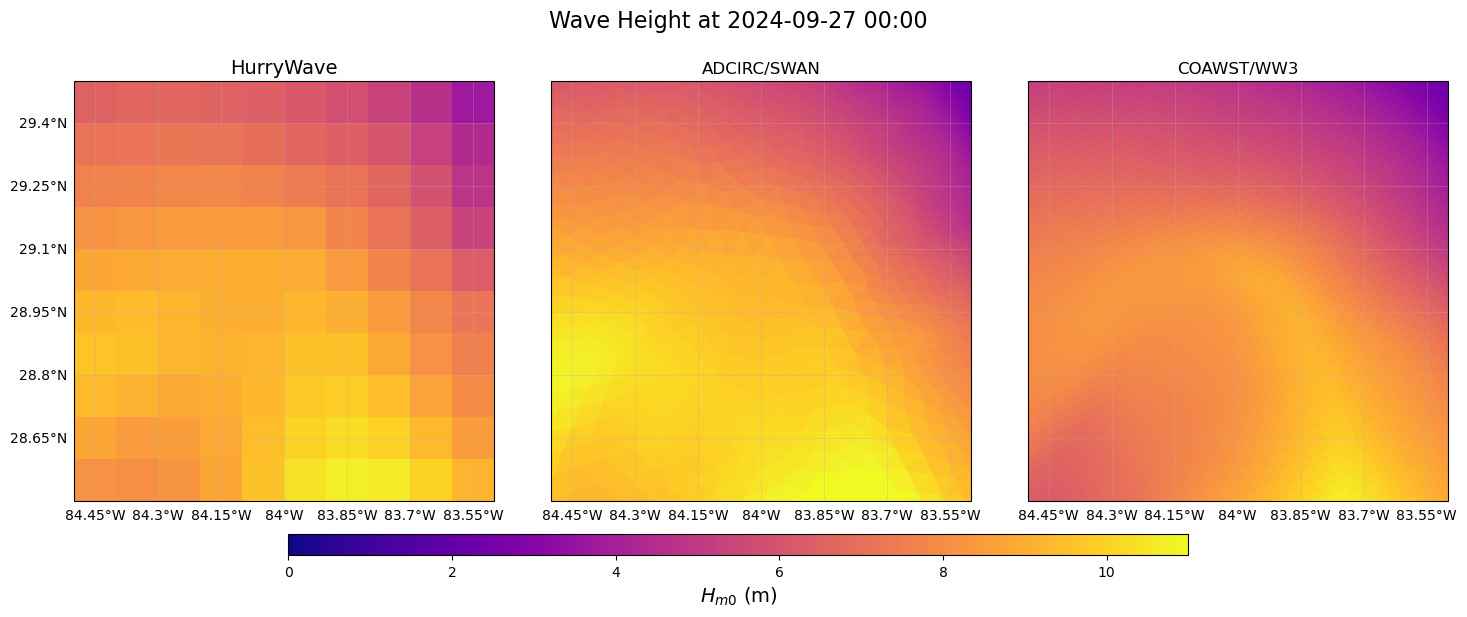

In [17]:
# High-res plot

lon_min, lon_max = -84.5, -83.5
lat_min, lat_max = 28.5, 29.5
extent = [lon_min, lon_max, lat_min, lat_max]
fig = plt.figure(figsize=(18, 6))

ax1 = _get_ax(fig, 1, 3, 1)
ax2 = _get_ax(fig, 1, 3, 2)
ax3 = _get_ax(fig, 1, 3, 3)

pcm1 = plot_hurrywave_panel(ax1, d_hw, vmin, vmax, cmap, extent, show_left_labels=True)
pcm2 = plot_adcirc_panel(ax2, d_ad, vmin, vmax, cmap, extent, show_left_labels=False)
pcm3 = plot_coawst_panel(ax3, d_cw, vmin, vmax, cmap, extent, show_left_labels=False)

# Leave room for bottom colorbar
fig.subplots_adjust(bottom=0.18, wspace=0.08)

# Horizontal colorbar across the bottom
cbar_ax = fig.add_axes([0.25, 0.09, 0.50, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(pcm3, cax=cbar_ax, orientation="horizontal")
cbar.set_label("$H_{m0}$ (m)", fontsize=14)

# Ensure ticks/label are on bottom (default, but explicit)
cbar.ax.xaxis.set_label_position("bottom")
cbar.ax.xaxis.set_ticks_position("bottom")

fig.suptitle("Wave Height at 2024-09-27 00:00", y=1., fontsize=16)
plt.savefig('F:/crs/proj/2025_NOPP_comparison/helene_figs/three_panel_Hmo_hires.png', dpi=300)
plt.show()

In [15]:
# Compute spacing

def haversine(lon1, lat1, lon2, lat2):
    R = 6371000.0
    dlon = np.deg2rad(lon2 - lon1)
    dlat = np.deg2rad(lat2 - lat1)
    a = np.sin(dlat/2)**2 + np.cos(np.deg2rad(lat1))*np.cos(np.deg2rad(lat2))*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


# ADCIRC
# triangle node indices (already 0-based)
# node coordinates
lon = d_ad["x"]
lat = d_ad["y"]

# triangle connectivity from the Triangulation object
tri_obj = d_ad["tri"]
triangles = tri_obj.triangles
mask = tri_obj.mask

if mask is not None:
    triangles = triangles[~mask]

# compute edge lengths
p1 = triangles[:, 0]
p2 = triangles[:, 1]
p3 = triangles[:, 2]

d12 = haversine(lon[p1], lat[p1], lon[p2], lat[p2])
d23 = haversine(lon[p2], lat[p2], lon[p3], lat[p3])
d31 = haversine(lon[p3], lat[p3], lon[p1], lat[p1])

edges = np.concatenate([d12, d23, d31])

print("ADCIRC/SWAN edge length stats (m)")
print("min   :", np.nanmin(edges))
print("median:", np.nanmedian(edges))
print("max   :", np.nanmax(edges))


# COAWST/WW3
x = d_cw['x']
y = d_cw['y']

# zonal spacing
dx = haversine(x[:, :-1], y[:, :-1], x[:, 1:], y[:, 1:])

# meridional spacing
dy = haversine(x[:-1, :], y[:-1, :], x[1:, :], y[1:, :])

spacing = np.concatenate([dx.ravel(), dy.ravel()])
print('\nCOAWST/WW3:')
print("Min spacing (m):", np.nanmin(spacing))
print("Median spacing (m):", np.nanmedian(spacing))
print("Max spacing (m):", np.nanmax(spacing))

# Hurrywave
x = d_hw['x']
y = d_hw['y']

# zonal spacing
dx = haversine(x[:, :-1], y[:, :-1], x[:, 1:], y[:, 1:])

# meridional spacing
dy = haversine(x[:-1, :], y[:-1, :], x[1:, :], y[1:, :])

spacing = np.concatenate([dx.ravel(), dy.ravel()])
print('\nHurrywave:')
print("Min spacing (m):", np.nanmin(spacing))
print("Median spacing (m):", np.nanmedian(spacing))
print("Max spacing (m):", np.nanmax(spacing))



ADCIRC/SWAN edge length stats (m)
min   : 14.625162281337909
median: 168.52568626965873
max   : 52222.67008871617

COAWST/WW3:
Min spacing (m): 1555.1020198411775
Median spacing (m): 1736.9672640303534
Max spacing (m): 2229.686703009712

Hurrywave:
Min spacing (m): 9575.804
Median spacing (m): 10572.908
Max spacing (m): 11119.747


In [11]:
d_ad

{'name': 'ADCIRC/SWAN',
 'time': np.datetime64('2024-09-27T00:00:00.000000000'),
 'x': array([-90.426596, -90.426874, -90.427234, ..., -85.704266, -85.700042,
        -85.70373 ]),
 'y': array([30.126747, 30.131148, 30.135214, ..., 30.097948, 30.099771,
        30.102258]),
 'tri': <matplotlib.tri._triangulation.Triangulation at 0x1e8d1539ab0>,
 'z': array([0.33688527, 0.33975232, 0.33995551, ..., 2.11923146,        nan,
               nan])}